In [1]:
!pip install -q kaggle

# Upload kaggle.json (only first time)
from google.colab import files
# files.upload()          # uncomment only when needed

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 141MB/s]



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Using device:", device)

print("Imports done!")

✅ Using device: cuda
Imports done!


In [7]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_data = torchvision.datasets.ImageFolder(
    "brain_tumor/Training",
    transform=train_tf
)

test_data = torchvision.datasets.ImageFolder(
    "brain_tumor/Testing",
    transform=test_tf
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

class_names = train_data.classes
print("Classes:", class_names)
print(len(train_data), "train |", len(test_data), "test")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
5600 train | 1600 test


In [8]:
# Model

class BrainCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*14*14, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 4)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = BrainCNN().to(device)

In [16]:
#  Training Function + Run Training

def train_model(model, train_loader, epochs=12, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"Starting training for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy tracking
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.2f}%")

    print("Training finished!")
    return model

model = train_model(model, train_loader, epochs=12, lr=0.0005)

Starting training for 12 epochs...
Epoch [1/12]  Loss: 1.7305  Train Acc: 68.54%
Epoch [2/12]  Loss: 0.6514  Train Acc: 76.82%
Epoch [3/12]  Loss: 0.5022  Train Acc: 81.16%
Epoch [4/12]  Loss: 0.4173  Train Acc: 84.54%
Epoch [5/12]  Loss: 0.3491  Train Acc: 87.04%
Epoch [6/12]  Loss: 0.3345  Train Acc: 87.68%
Epoch [7/12]  Loss: 0.3431  Train Acc: 88.14%
Epoch [8/12]  Loss: 0.2713  Train Acc: 89.84%
Epoch [9/12]  Loss: 0.2138  Train Acc: 91.66%
Epoch [10/12]  Loss: 0.2006  Train Acc: 92.59%
Epoch [11/12]  Loss: 0.1918  Train Acc: 93.36%
Epoch [12/12]  Loss: 0.1861  Train Acc: 93.50%
Training finished!


In [17]:
#  Evaluate on Test Set

@torch.no_grad()
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%  ({correct}/{total} correct)")

    return np.array(all_preds), np.array(all_labels), accuracy

# Run evaluation
print("Evaluating model on test set...")
test_preds, test_labels, test_acc = evaluate_model(model, test_loader)

Evaluating model on test set...
Test Accuracy: 88.31%  (1413/1600 correct)


In [18]:
#  Grad-CAM Implementation

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def save_activation(module, input, output):
            self.activations = output.detach()

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(save_activation)
        target_layer.register_full_backward_hook(save_gradient)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        logit = self.model(input_tensor)

        if class_idx is None:
            class_idx = logit.argmax(dim=1).item()

        score = logit[0, class_idx]
        score.backward()

        # Global average pooling on gradients
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)

        # Weighted sum of activations
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        cam = torch.relu(cam)

        # Normalize to [0,1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy()

In [19]:
#  Upload Image

from google.colab import files
from PIL import Image
import torchvision.transforms as transforms

print("Upload your brain MRI image (JPG/PNG)...")
uploaded = files.upload()

# Get the first uploaded file
file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

# Open image
custom_img = Image.open(file_name).convert('RGB')

Upload your brain MRI image (JPG/PNG)...


Saving brain-tumor-blog-photo.jpg to brain-tumor-blog-photo.jpg
Uploaded file: brain-tumor-blog-photo.jpg


In [20]:
#  Predict & Grad-CAM on Custom Image
custom_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor = custom_transform(custom_img).unsqueeze(0).to(device)  # add batch dimension

# Get prediction
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)[0]
    pred_class_idx = output.argmax(dim=1).item()
    confidence = probabilities[pred_class_idx].item() * 100

pred_class_name = class_names[pred_class_idx]

print(f"\nPrediction: {pred_class_name}")
print(f"Confidence: {confidence:.2f}%")
print("Probabilities:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name:12}: {probabilities[i].item()*100:5.2f}%")

# Generate Grad-CAM
gradcam = GradCAM(model, model.features[-3])  # last conv layer (adjust index if needed)
heatmap = gradcam.generate(input_tensor, pred_class_idx)


Prediction: notumor
Confidence: 100.00%
Probabilities:
  glioma      :  0.00%
  meningioma  :  0.00%
  notumor     : 100.00%
  pituitary   :  0.00%


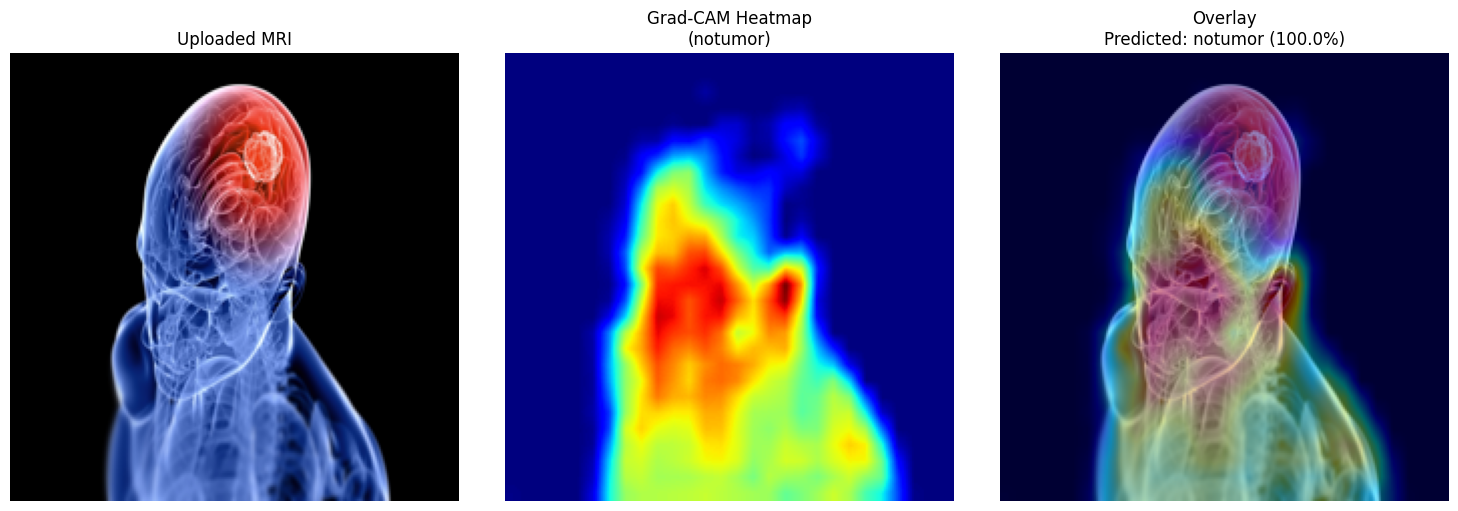

In [21]:
#  Visualization

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Prepare original image for display
img_display = np.array(custom_img.resize((224, 224))) / 255.0

# Resize heatmap to match image size
heatmap_resized = cv2.resize(heatmap, (224, 224))

# Create colored heatmap
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

# Overlay
overlay = img_display * 0.6 + heatmap_colored * 0.4

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_display)
plt.title("Uploaded MRI")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap='jet')
plt.title(f"Grad-CAM Heatmap\n({pred_class_name})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay\nPredicted: {pred_class_name} ({confidence:.1f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()